In [21]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import kwant

from scipy.sparse.linalg import eigsh
from scipy.optimize import minimize_scalar


FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [3]:
Nx = 8
Ny = 6

t1 = 1.0
t2 = 1.0
mu = 0.0

SUBS = ["A", "B", "C", "D"]

In [4]:
def normal_host_matrix():

    index = {
        (ix, iy, sub): 4 * (ix + Nx * iy) + SUBS.index(sub)
        for iy in range(Ny)
        for ix in range(Nx)
        for sub in SUBS
    }

    N = 4 * Nx * Ny
    H = np.zeros((N, N), dtype=complex)

    np.fill_diagonal(H, -mu)


    def add_hopping(site1, site2, t):

        i = index[site1]
        j = index[site2]

        H[i, j] += -t
        H[j, i] += -t


    for iy in range(Ny):
        for ix in range(Nx):

            # Intra-cell nearest-neighbor bonds
            for s1, s2 in [
                ("A", "B"),
                ("B", "C"),
                ("C", "D"),
                ("D", "A"),
            ]:
                add_hopping((ix, iy, s1), (ix, iy, s2), t1)

            # Inter-cell nearest-neighbor bonds with PBC
            add_hopping(
                (ix, iy, "C"),
                (ix, (iy + 1) % Ny, "A"),
                t1
            )

            add_hopping(
                (ix, iy, "B"),
                ((ix + 1) % Nx, iy, "D"),
                t1
            )

            # Intra-cell diagonal hopping
            add_hopping((ix, iy, "A"), (ix, iy, "C"), t2)
            add_hopping((ix, iy, "B"), (ix, iy, "D"), t2)

    return H, index

In [5]:
TOP = [
    (0, 0, "A")
]

SQUARE = [
    (0, 0, "A"),
    (0, 0, "B"),
    (0, 0, "C"),
    (0, 0, "D"),
]

OCTAGON = [
    (0, 0, "D"),
    (1, 0, "B"),
    (1, 0, "A"),
    (1, 1, "C"),
    (1, 1, "B"),
    (0, 1, "D"),
    (0, 1, "C"),
    (0, 0, "A"),
]

In [9]:
def channel_vector(cluster, index, m=0):

    phi = np.zeros(len(index), dtype=complex)
    Nc = len(cluster)

    for j, site in enumerate(cluster):
        phase = np.exp(1j * 2 * np.pi * m * j / Nc)
        phi[index[site]] = phase / np.sqrt(Nc)

    return phi


def flat_band_weight(cluster, m=0):

    phi = channel_vector(cluster, index, m=m)

    overlaps = evecs[:, flat_mask].conj().T @ phi

    return np.sum(np.abs(overlaps)**2).real


def projected_spectral_function(cluster):

    phi = channel_vector(cluster, index, m=0)

    weights = np.abs(evecs.conj().T @ phi)**2
    diff = E_values[:, None] - evals[None, :]

    A = np.sum(
        weights[None, :] * eta / (np.pi * (diff**2 + eta**2)),
        axis=1
    )

    return A

In [10]:
H, index = normal_host_matrix()

evals, evecs = np.linalg.eigh(H)

flat_tol = 1e-10
flat_mask = np.abs(evals) < flat_tol

print("Number of zero-energy states =", np.sum(flat_mask))

Number of zero-energy states = 49


In [11]:
E_values = np.linspace(-0.55, 0.55, 900)
eta = 0.025

In [12]:
A_top = projected_spectral_function(TOP)
A_square = projected_spectral_function(SQUARE)
A_octagon = projected_spectral_function(OCTAGON)

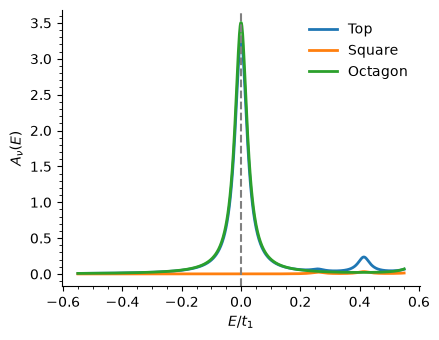

In [14]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(E_values, A_top, lw=2, label="Top")
ax.plot(E_values, A_square, lw=2, label="Square")
ax.plot(E_values, A_octagon, lw=2, label="Octagon")

ax.axvline(0, color="gray", ls="--")

ax.set_xlabel(r"$E/t_1$")
ax.set_ylabel(r"$A_\nu(E)$")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "projected_spectral_function.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [15]:
P_top = flat_band_weight(TOP, m=0)
P_square = flat_band_weight(SQUARE, m=0)
P_octagon = flat_band_weight(OCTAGON, m=0)

print("Top     =", P_top)
print("Square  =", P_square)
print("Octagon =", P_octagon)

Top     = 0.2573614409531922
Square  = 1.4762384679095455e-31
Octagon = 0.2752699630576868


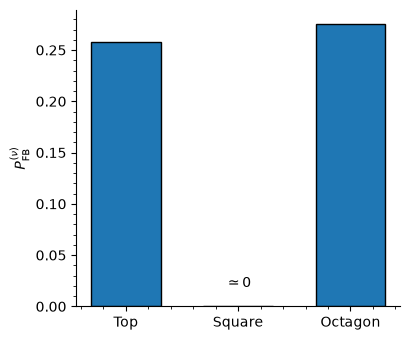

In [16]:
names = ["Top", "Square", "Octagon"]
P_sym = [P_top, P_square, P_octagon]


fig, ax = plt.subplots(figsize=(4.2, 3.5))

ax.bar(
    names, P_sym,
    width=0.62,
    edgecolor="black"
)

ax.set_ylabel(r"$P_{\rm FB}^{(\nu)}$")

ax.text(
    1, 0.015, r"$\simeq 0$",
    ha="center", va="bottom"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "flatband_projection_symmetric.pdf",
    dpi=600, bbox_inches="tight"
)

plt.show()

In [17]:
m_square = np.arange(4)

P_square_m = np.array([
    flat_band_weight(SQUARE, m=m)
    for m in m_square
])

print(P_square_m)

[1.47623847e-31 3.29234157e-01 3.62365018e-01 3.29234157e-01]


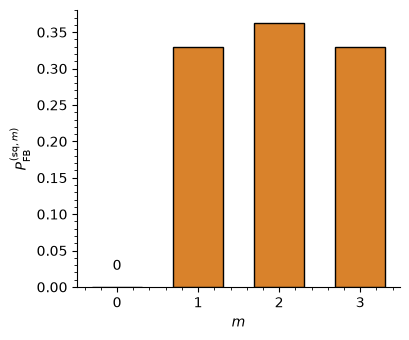

In [18]:
fig, ax = plt.subplots(figsize=(4.2, 3.5))

ax.bar(
    m_square, P_square_m,
    width=0.62,
    color="#D9822B",
    edgecolor="black"
)

ax.set_xlabel(r"$m$")
ax.set_ylabel(r"$P_{\rm FB}^{(\mathrm{sq},m)}$")

ax.set_xticks(m_square)

ax.text(
    0, 0.018, r"$0$",
    ha="center", va="bottom"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "flatband_projection_square_channels.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [19]:
m_octagon = np.arange(8)

P_octagon_m = np.array([
    flat_band_weight(OCTAGON, m=m)
    for m in m_octagon
])

print(P_octagon_m)

[0.27526996 0.19081805 0.19795193 0.34701636 0.29482402 0.34701636
 0.19795193 0.19081805]


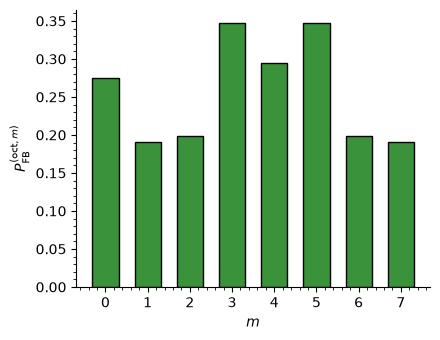

In [35]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

ax.bar(
    m_octagon, P_octagon_m,
    width=0.62,
    color="#3A923A",
    edgecolor="black"
)

ax.set_xlabel(r"$m$")
ax.set_ylabel(r"$P_{\rm FB}^{(\mathrm{oct},m)}$")

ax.set_xticks(m_octagon)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "flatband_projection_octagon_channels.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [43]:
# Bloch Hamiltonian

def bloch_hamiltonian(k1, k2, t2):

    return -np.array([
        [0,  t1, t2 + t1 * np.exp(-1j * k2), t1],
        [t1, 0,  t1, t2 + t1 * np.exp(-1j * k1)],
        [t2 + t1 * np.exp(1j * k2), t1, 0, t1],
        [t1, t2 + t1 * np.exp(1j * k1), t1, 0]
    ], dtype=complex)


def normal_host_matrix(Nx, Ny, t1, t2, mu=0.0):

    index = {
        (ix, iy, sub): 4 * (ix + Nx * iy) + SUBS.index(sub)
        for iy in range(Ny)
        for ix in range(Nx)
        for sub in SUBS
    }

    N = 4 * Nx * Ny
    H = np.zeros((N, N), dtype=complex)

    np.fill_diagonal(H, -mu)

    def add_hopping(site1, site2, t):

        i = index[site1]
        j = index[site2]

        H[i, j] += -t
        H[j, i] += -t

    for iy in range(Ny):
        for ix in range(Nx):

            # Intra-cell nearest-neighbor bonds
            for s1, s2 in [
                ("A", "B"),
                ("B", "C"),
                ("C", "D"),
                ("D", "A"),
            ]:
                add_hopping((ix, iy, s1), (ix, iy, s2), t1)

            # Inter-cell nearest-neighbor bonds with PBC
            add_hopping(
                (ix, iy, "C"),
                (ix, (iy + 1) % Ny, "A"),
                t1
            )

            add_hopping(
                (ix, iy, "B"),
                ((ix + 1) % Nx, iy, "D"),
                t1
            )

            # Intra-cell diagonal hopping
            add_hopping((ix, iy, "A"), (ix, iy, "C"), t2)
            add_hopping((ix, iy, "B"), (ix, iy, "D"), t2)

    return H, index

In [44]:
def tracked_band_peak(t2):

    Nk = 61
    eta = 0.035

    kvals = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

    energies = []

    for k1 in kvals:
        for k2 in kvals:
            vals = np.linalg.eigvalsh(
                bloch_hamiltonian(k1, k2, t2)
            )

            # Band connected continuously to the E=0 flat band
            energies.append(vals[1])

    energies = np.array(energies)

    Egrid = np.linspace(-1.25, 0.20, 800)

    dos = np.exp(
        -0.5 * ((Egrid[:, None] - energies[None, :]) / eta)**2
    ).sum(axis=1)

    return Egrid[np.argmax(dos)]

In [45]:
# Chemical potential following the flat-band-derived peak

t2_values = np.linspace(0.0, 1.0, 9)

mu_star = np.array([
    tracked_band_peak(t2)
    for t2 in t2_values
])


for t2, mu in zip(t2_values, mu_star):
    print(f"t2/t1 = {t2:.3f}   mu* = {mu:+.4f}")

t2/t1 = 0.000   mu* = -0.9723
t2/t1 = 0.125   mu* = -0.8489
t2/t1 = 0.250   mu* = -0.7237
t2/t1 = 0.375   mu* = -0.5985
t2/t1 = 0.500   mu* = -0.4733
t2/t1 = 0.625   mu* = -0.3481
t2/t1 = 0.750   mu* = -0.2228
t2/t1 = 0.875   mu* = -0.0976
t2/t1 = 1.000   mu* = +0.0004


In [46]:
clusters = {
    "Top": TOP,
    "Square": SQUARE,
    "Octagon": OCTAGON,
}

geometries = ["Top", "Square", "Octagon"]

In [47]:
# Projected spectral response at mu*

eta_proj = 0.025

A_track = {
    "Top": [],
    "Square": [],
    "Octagon": [],
}


for t2, mu0 in zip(t2_values, mu_star):

    H, index = normal_host_matrix(
        Nx=Nx, Ny=Ny,
        t1=t1, t2=t2,
        mu=0.0
    )

    evals, evecs = np.linalg.eigh(H)


    for geometry in geometries:

        phi = channel_vector(
            clusters[geometry], index,
            m=0
        )

        weights = np.abs(evecs.conj().T @ phi)**2

        A0 = np.sum(
            weights * eta_proj
            / (np.pi * ((mu0 - evals)**2 + eta_proj**2))
        )

        A_track[geometry].append(A0)


for geometry in geometries:
    A_track[geometry] = np.array(A_track[geometry])

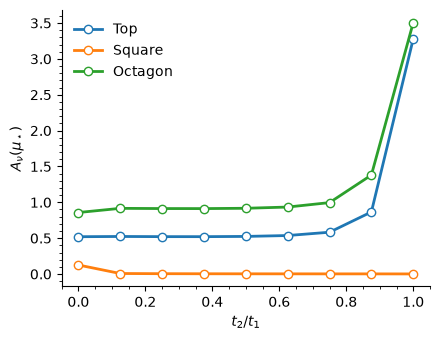

In [48]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(
    t2_values, A_track["Top"],
    "o-", lw=2, mfc="white",
    label="Top"
)

ax.plot(
    t2_values, A_track["Square"],
    "o-", lw=2, mfc="white",
    label="Square"
)

ax.plot(
    t2_values, A_track["Octagon"],
    "o-", lw=2, mfc="white",
    label="Octagon"
)


ax.set_xlabel(r"$t_2/t_1$")
ax.set_ylabel(r"$A_\nu(\mu_\star)$")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "adatom_projected_spectral_response.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [49]:
Wd_t2 = {
    "Top": [],
    "Square": [],
    "Octagon": [],
}


for t2, mu0 in zip(t2_values, mu_star):

    print(f"\nt2/t1 = {t2:.3f}   mu* = {mu0:+.4f}")

    params_t2 = {
        "mu": mu0,
        "Delta": Delta,
        "t1": t1,
        "t2": t2,
        "eps_d": eps_d,
        "Jd": 0.0
    }


    for geometry in geometries:

        fsyst, ad_site = systems[geometry]

        Jstar, E, vec = find_crossing(
            fsyst, params_t2,
            Jmax=3.0
        )

        # Adatom weight
        iad = fsyst.id_by_site[ad_site]
        ad_slice = slice(4 * iad, 4 * iad + 4)

        Wd = np.sum(
            np.abs(vec[ad_slice])**2
        ).real

        Wd_t2[geometry].append(Wd)

        print(
            f"{geometry:8s}  "
            f"Jc = {Jstar:.4f}   "
            f"W_d = {Wd:.4f}"
        )


for geometry in geometries:
    Wd_t2[geometry] = np.array(Wd_t2[geometry])


t2/t1 = 0.000   mu* = -0.9723
Top       Jc = 0.5306   W_d = 0.3186
Square    Jc = 0.8591   W_d = 0.5498
Octagon   Jc = 0.7403   W_d = 0.2215

t2/t1 = 0.125   mu* = -0.8489
Top       Jc = 0.5119   W_d = 0.3205
Square    Jc = 0.8347   W_d = 0.6704
Octagon   Jc = 0.7534   W_d = 0.2172

t2/t1 = 0.250   mu* = -0.7237
Top       Jc = 0.5035   W_d = 0.3156
Square    Jc = 0.7913   W_d = 0.7468
Octagon   Jc = 0.7722   W_d = 0.2124

t2/t1 = 0.375   mu* = -0.5985
Top       Jc = 0.5070   W_d = 0.3060
Square    Jc = 0.7586   W_d = 0.7934
Octagon   Jc = 0.7964   W_d = 0.2068

t2/t1 = 0.500   mu* = -0.4733
Top       Jc = 0.5238   W_d = 0.2922
Square    Jc = 0.7329   W_d = 0.8269
Octagon   Jc = 0.8283   W_d = 0.2002

t2/t1 = 0.625   mu* = -0.3481
Top       Jc = 0.5609   W_d = 0.2727
Square    Jc = 0.7118   W_d = 0.8527
Octagon   Jc = 0.8716   W_d = 0.1925

t2/t1 = 0.750   mu* = -0.2228
Top       Jc = 0.6342   W_d = 0.2456
Square    Jc = 0.6939   W_d = 0.8732
Octagon   Jc = 0.9305   W_d = 0.1837

t2/t1

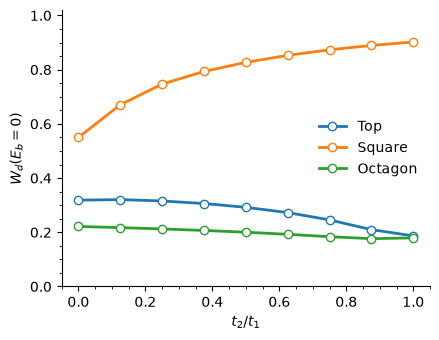

In [50]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(
    t2_values, Wd_t2["Top"],
    "o-", lw=2, mfc="white",
    label="Top"
)

ax.plot(
    t2_values, Wd_t2["Square"],
    "o-", lw=2, mfc="white",
    label="Square"
)

ax.plot(
    t2_values, Wd_t2["Octagon"],
    "o-", lw=2, mfc="white",
    label="Octagon"
)


ax.set_xlabel(r"$t_2/t_1$")
ax.set_ylabel(r"$W_d(E_b=0)$")

ax.set_ylim(0, 1.02)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "adatom_weight_vs_t2.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()